In [1]:
# ==========================================
# CELL 1: IMPORT THƯ VIỆN
# ==========================================
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Kiểm tra xem GPU có sẵn sàng không
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [2]:
# ==========================================
# CELL 2: LOAD DATASET VÀ DATALOADER
# ==========================================
class SketchDataset(Dataset):
    def __init__(self, broken_dir, complete_dir, transform=None):
        self.broken_dir = broken_dir
        self.complete_dir = complete_dir
        self.transform = transform
        
        # Lấy danh sách tên file từ thư mục broken (ảnh bị đứt)
        self.filenames = [f for f in os.listdir(broken_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        
    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        filename = self.filenames[idx]
        
        broken_path = os.path.join(self.broken_dir, filename)
        complete_path = os.path.join(self.complete_dir, filename)
        
        # Load ảnh dưới dạng Grayscale (L) để mô hình nhẹ hơn
        broken_img = Image.open(broken_path).convert('L')
        complete_img = Image.open(complete_path).convert('L')
        
        if self.transform:
            broken_img = self.transform(broken_img)
            complete_img = self.transform(complete_img)
            
        return broken_img, complete_img

# --- CẤU HÌNH ĐƯỜNG DẪN (Sửa lại cho đúng với Kaggle của bạn) ---
# Ví dụ: BROKEN_DIR = '/kaggle/input/your-dataset-name/broken_sketches'
BROKEN_DIR = '/kaggle/input/datasets/vunhuduc/test-sketch-broken-data/(4)_val_sketch_hed_degraded' 
COMPLETE_DIR = '/kaggle/input/datasets/vunhuduc/test-sketch-broken-data/(4)_sketch_hed_merged'

# Kích thước ảnh: 256x256 là đủ tốt cho nét vẽ, có thể tăng lên 512 nếu muốn
IMG_SIZE = 256
BATCH_SIZE = 16

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(), # Chuyển thành tensor và chuẩn hóa về [0, 1]
])

# Khởi tạo Dataset
full_dataset = SketchDataset(BROKEN_DIR, COMPLETE_DIR, transform=transform)

# Chia tập Train (80%) và Validation (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Số lượng ảnh Train: {len(train_dataset)}")
print(f"Số lượng ảnh Validation: {len(val_dataset)}")

Số lượng ảnh Train: 1366
Số lượng ảnh Validation: 342


In [3]:
# ==========================================
# CELL 3: KIẾN TRÚC LIGHTWEIGHT U-NET
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class LightUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(LightUNet, self).__init__()
        
        # Encoder (Downsampling) - Filters nhỏ để mô hình nhẹ
        self.down1 = DoubleConv(in_channels, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(32, 64)
        self.pool3 = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(64, 128)
        
        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(128, 64) # 128 vì nối thêm skip-connection
        
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(64, 32)
        
        self.up3 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(32, 16)
        
        # Output layer
        self.out_conv = nn.Conv2d(16, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        
        # Bottleneck
        bn = self.bottleneck(p3)
        
        # Decoder + Skip Connections
        u1 = self.up1(bn)
        u1 = torch.cat([u1, d3], dim=1)
        u1 = self.conv_up1(u1)
        
        u2 = self.up2(u1)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv_up2(u2)
        
        u3 = self.up3(u2)
        u3 = torch.cat([u3, d1], dim=1)
        u3 = self.conv_up3(u3)
        
        # Không dùng Sigmoid ở đây vì sẽ dùng BCEWithLogitsLoss cho ổn định số học
        return self.out_conv(u3)

# Khởi tạo mô hình
model = LightUNet(in_channels=1, out_channels=1).to(device)
print(model)

LightUNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  

In [4]:
# ==========================================
# CELL 4: QUÁ TRÌNH TRAINING (CÓ TQDM)
# ==========================================
from tqdm.notebook import tqdm  # Thư viện tạo thanh tiến trình tối ưu cho Kaggle/Jupyter

EPOCHS = 50
LEARNING_RATE = 1e-3

# Loss và Optimizer
criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Lưu trữ loss để vẽ biểu đồ
train_losses = []
val_losses = []

# Vòng lặp chính qua các Epoch
for epoch in range(EPOCHS):
    # --- TRAIN PHASE ---
    model.train()
    running_train_loss = 0.0
    
    # Thêm tqdm vào train_loader
    train_loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] - Training", leave=False)
    
    for broken_imgs, complete_imgs in train_loop:
        broken_imgs, complete_imgs = broken_imgs.to(device), complete_imgs.to(device)
        
        optimizer.zero_grad()
        outputs = model(broken_imgs)
        
        loss = criterion(outputs, complete_imgs)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        # Cập nhật loss hiển thị liên tục trên thanh tqdm
        train_loop.set_postfix(loss=loss.item())
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    
    # Thêm tqdm vào val_loader (tùy chọn, giúp biết tiến trình val)
    val_loop = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}] - Validation", leave=False)
    
    with torch.no_grad():
        for broken_imgs, complete_imgs in val_loop:
            broken_imgs, complete_imgs = broken_imgs.to(device), complete_imgs.to(device)
            outputs = model(broken_imgs)
            loss = criterion(outputs, complete_imgs)
            
            running_val_loss += loss.item()
            val_loop.set_postfix(loss=loss.item())
            
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # In kết quả tổng hợp sau mỗi Epoch
    print(f"Epoch [{epoch+1}/{EPOCHS}] hoàn thành | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# Lưu weights của mô hình sau khi train xong
torch.save(model.state_dict(), "light_unet_sketch_fixer.pth")
print("\n🎉 Đã hoàn thành quá trình training và lưu mô hình thành công!")

Epoch [1/50] - Training:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch [1/50] - Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [1/50] hoàn thành | Train Loss: 0.3761 | Val Loss: 0.3011


Epoch [2/50] - Training:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch [2/50] - Validation:   0%|          | 0/22 [00:00<?, ?it/s]

...

Epoch [49/50] - Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [49/50] hoàn thành | Train Loss: 0.1673 | Val Loss: 0.1669


Epoch [50/50] - Training:   0%|          | 0/86 [00:00<?, ?it/s]

Epoch [50/50] - Validation:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch [50/50] hoàn thành | Train Loss: 0.1673 | Val Loss: 0.1673

🎉 Đã hoàn thành quá trình training và lưu mô hình thành công!


In [5]:
# ==========================================
# CELL 5: IN ĐÁNH GIÁ KẾT QUẢ
# ==========================================
print("=== KẾT QUẢ TRAINING ===")
print(f"Tổng số Epoch: {EPOCHS}")
print(f"Train Loss cuối cùng: {train_losses[-1]:.6f}")
print(f"Validation Loss cuối cùng: {val_losses[-1]:.6f}")

if val_losses[-1] < train_losses[-1]:
    print("Mô hình tổng quát hóa tốt (Không bị Overfitting).")
else:
    print("Lưu ý: Val Loss cao hơn Train Loss, có thể cần thêm Dropout hoặc Data Augmentation nếu khoảng cách quá lớn.")

=== KẾT QUẢ TRAINING ===
Tổng số Epoch: 50
Train Loss cuối cùng: 0.167297
Validation Loss cuối cùng: 0.167328
Lưu ý: Val Loss cao hơn Train Loss, có thể cần thêm Dropout hoặc Data Augmentation nếu khoảng cách quá lớn.


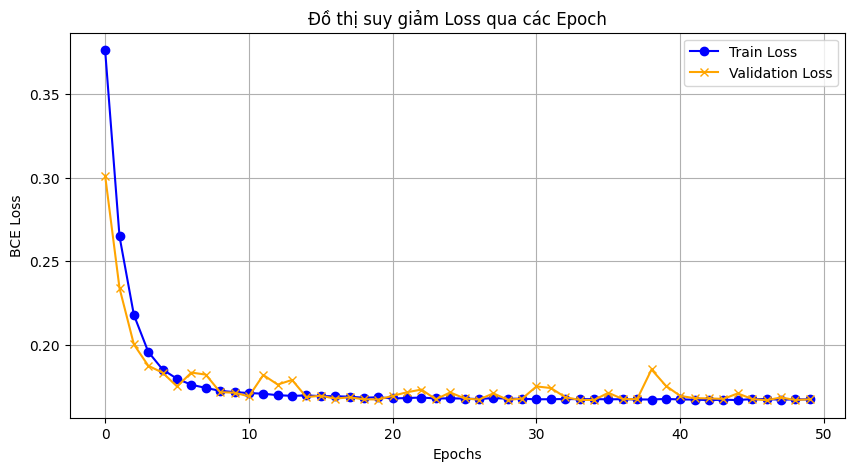

In [6]:
# ==========================================
# CELL 6: VẼ BIỂU ĐỒ LOSS
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', marker='o')
plt.plot(val_losses, label='Validation Loss', color='orange', marker='x')
plt.title('Đồ thị suy giảm Loss qua các Epoch')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)
plt.show()

Đang infer ảnh: /kaggle/input/datasets/vunhuduc/test-sketch-broken-data/(4)_val_sketch_hed_degraded/6_pants__19829_4435.png


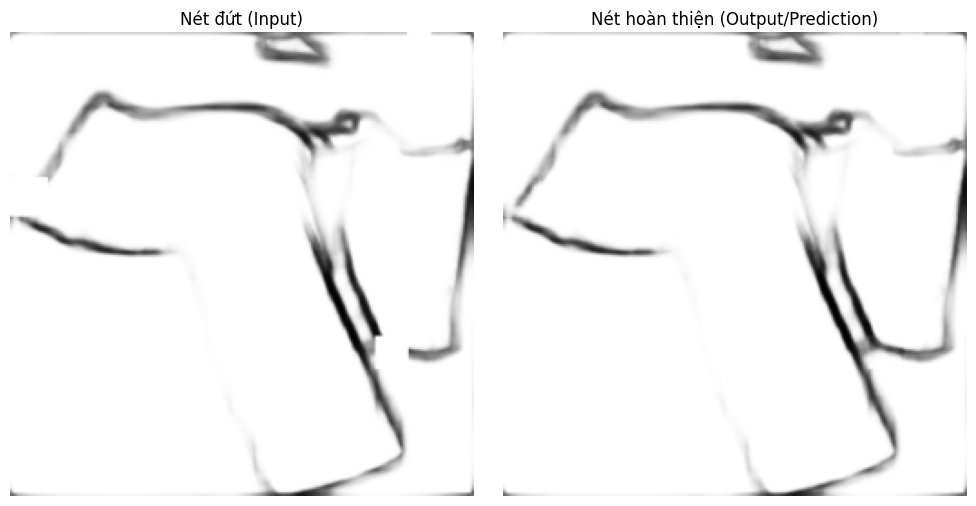

In [7]:
# ==========================================
# CELL 7: INFERENCE VÀ TRỰC QUAN HÓA TRỰC TIẾP
# ==========================================
def infer_and_show(model, image_path, device):
    model.eval()
    
    # Load và preprocess ảnh
    img = Image.open(image_path).convert('L')
    input_tensor = transform(img).unsqueeze(0).to(device) # Thêm batch dimension
    
    with torch.no_grad():
        output = model(input_tensor)
        # Sử dụng Sigmoid để đưa giá trị output về [0, 1] vì ta đã dùng BCEWithLogitsLoss
        output = torch.sigmoid(output)
    
    # Chuyển tensor về numpy array để vẽ
    input_img = input_tensor.cpu().squeeze().numpy()
    pred_img = output.cpu().squeeze().numpy()
    
    # Trực quan hóa
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("Nét đứt (Input)")
    axes[0].axis('off')
    
    axes[1].imshow(pred_img, cmap='gray')
    axes[1].set_title("Nét hoàn thiện (Output/Prediction)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# --- Lấy ngẫu nhiên 1 file trong tập validation để test ---
# Bạn có thể thay test_img_path bằng đường dẫn tới ảnh bất kỳ của bạn
test_img_path = os.path.join(BROKEN_DIR, val_dataset.dataset.filenames[val_dataset.indices[3]])
print(f"Đang infer ảnh: {test_img_path}")
infer_and_show(model, test_img_path, device)